# Build a Micro-Transformer for DNA sequence

## Section 1: The Positional Encoding (The "Map")
Since Transformers process all DNA bases at once, they are "bag-of-words" models unless we add position. It is thus essential to perform element-wise addition between the content embeddings ($x$) and the first $N$ steps of the pre-computed sinusoidal signals. This ensures that even though the Self-Attention mechanism is permutation-invariant, the resulting vectors contain a unique 'time-stamp' for their position in the sequence.
* `__init__`: create Sine and Cosine waves of different frequencies.
* `forward`: add sinusoidal signals to embeddings.
* Why add but not concatenate? The Transformer is surprisingly good at "untangling" this. Because the d_model is so large (512 in real models), the model learns to use some dimensions for Meaning and others for Position. Adding them is mathematically efficient and keeps the tensor size small, which makes the model faster.

The Code Goal: Create a class PositionalEncoding(nn.Module) that adds a unique constant vector to each DNA base embedding based on its index (1, 2, 3...). For each DNA in the batch, it adds exactly the same cosine/sine positional vectors.

The Positional encoding is **independent** of content DNA sequence, so it's really a universal thing.



In [2]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        
        # 1. Create a matrix of shape [max_len, d_model] filled with zeros
        pe = torch.zeros(max_len, d_model)
        
        # 2. Create a vector of positions [0, 1, 2, ..., max_len-1]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        # 3. Calculate the "division term" for the frequencies
        # We use the formula from the paper: 10000^(2i/d_model)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # 4. Fill the even indices (0, 2, 4...) with Sine
        pe[:, 0::2] = torch.sin(position * div_term)
        
        # 5. Fill the odd indices (1, 3, 5...) with Cosine
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # 6. Add a batch dimension and register as a buffer
        pe = pe.unsqueeze(0) # Shape becomes [1, max_len, d_model]
        # We use register_buffer to ensure that pe is not treated as a model parameter (it won't be updated during training)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        x: Tensor of shape [batch_size, seq_len, d_model]
        """
        # Add the positional encoding to the embeddings
        # We slice self.pe to match the actual seq_len of the input x
        x = x + self.pe[:, :x.size(1), :]
        return x

Visualize the Positional Matrix:
* The "Y-Axis" (Sequence Position): Each row represents a position in the DNA (Base 0, Base 1, etc.). Notice how every row is unique—this is how the model knows which base it's looking at.
* The "X-Axis" (Embedding Dimensions): **we assign "microscopic" to low dimensions while "big picture" to high dimensions through wavelength**
  * Left Side (Low Dimensions):  These are high-frequency sine waves: The wave completes a full cycle (from -1 back to 1) every few bases. They help the model distinguish between immediate neighbors (e.g., Position 4 vs. Position 5).
  * Right Side (High Dimensions): These are low-frequency waves: The wave is so "long" that it might not even complete a single cycle across your entire DNA sequence. They help the model understand long-range relationships (e.g., "Am I at the beginning or the end of the entire gene?").
* Symmetry: You’ll see vertical "strips." This is the alternating Sine (even indices) and Cosine (odd indices) pattern that allows the model to calculate relative positions using trigonometric identities.

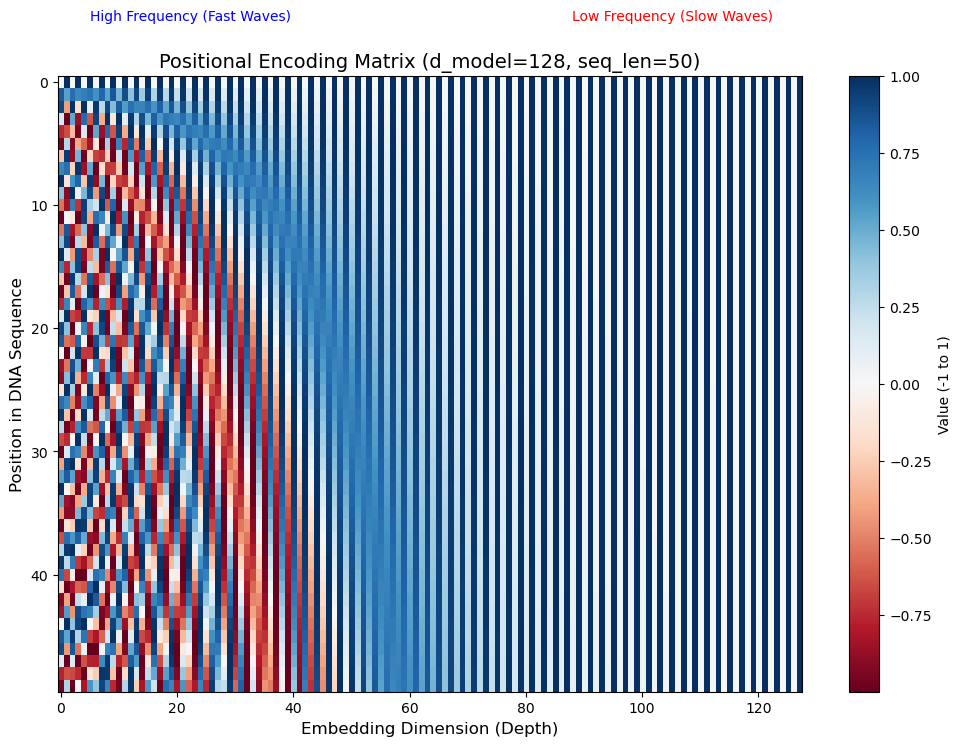

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_pe(d_model=128, max_len=100):
    # 1. Instantiate the layer
    pe_layer = PositionalEncoding(d_model=d_model, max_len=max_len)
    
    # 2. Extract the matrix (remove batch dimension and move to CPU)
    # Shape: [max_len, d_model]
    pe_matrix = pe_layer.pe.squeeze(0).cpu().numpy()

    # 3. Create the plot
    plt.figure(figsize=(12, 8))
    plt.imshow(pe_matrix, cmap='RdBu', aspect='auto')
    
    # Formatting
    plt.colorbar(label="Value (-1 to 1)")
    plt.title(f"Positional Encoding Matrix (d_model={d_model}, seq_len={max_len})", fontsize=14)
    plt.xlabel("Embedding Dimension (Depth)", fontsize=12)
    plt.ylabel("Position in DNA Sequence", fontsize=12)
    
    # Adding descriptive text for the README
    plt.text(5, -5, "High Frequency (Fast Waves)", color='blue', fontsize=10)
    plt.text(d_model-40, -5, "Low Frequency (Slow Waves)", color='red', fontsize=10)
    
    plt.show()

# Run the visualization
visualize_pe(d_model=128, max_len=50)

## Section 2: The Multi-Head Attention (The "Brain")
Create `class MultiHeadAttention(nn.Module)`
### The Math: Implement the Scaled Dot-Product Attention:
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$
The shape of *Q, K, V* are identical tensor of *(batch_size, sequence_length, d_model)*.
  * Suppose you have 10 sequences each with length 30, then batch_size=10, sequence_length=10. 
  * If *d_model=512*, every single base in the sequence is represented by 512 different features as a vector.
### 2.1 Linear Projection
* `self.w_q = nn.Linear(d_model, d_model)` sets input and output features as `d_model`
* `Q = self.w_q(q)` calculates
Note that the dimension of Q is (batch_size, sequence_len, d_model), pytorch detects the `d_model` matches the `input_features` of `self.w_q`, so it will parallelize by batch and bases automatically.
$$\text{Output} = q \times W^T + b$$

### 2.2 The Multi-Head Split
```
Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
```
* Shape change: [batch, seq_len, 512] $\rightarrow$ [batch, num_heads, seq_len, 64]
* Why we do this: By moving num_heads to the 2nd dimension, PyTorch treats the 8 heads like a "mini-batch." This allows us to calculate attention for all 8 heads simultaneously using one fast matrix multiplication $\rightarrow$ more efficient
* Each head looks at different subspace of the 512-dimensional embedding
  * Head 1 might take the first 64 numbers and specialize in "Looking for TATA boxes."
  * Head 2 might take the next 64 numbers and specialize in "Looking for GC-rich regions."
  * Head 3 might focus on "Long-range interactions."

### 2.3 Scale Dot-Product Attention
```
scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
```
* The Math: We multiply the Queries by the Keys. If a Query and Key match, the result is a high number.
* The Division (/ math.sqrt(d_k)): Crucial! As the dimension $d_k$ grows, the dot products get very large in magnitude. This pushes the softmax into a region where gradients are almost zero (the "vanishing gradient" problem). Dividing by the square root keeps the variance stable at 1, ensuring the model can actually learn.

### 2.4 Softmax & Weighting
```
attention = F.softmax(scores, dim=-1) # Turn scores into probabilities (0 to 1) -> weights
out = torch.matmul(attention, V)      # Multiply weights to value
```
The Logic: attention is your heatmap. If position 5 has a 0.9 score for position 10, the model "grabs" 90% of the information from the Value vector at position 10.

### 2.5 Recombining the heads
```
out = out.transpose(1, 2).contiguous().view(batch_size, -1, self.num_heads * self.d_k)
return self.fc_out(out) # One last linear layer to "mix" the information from all heads
```
We glue the 8 heads (each 64-dim) back together into a single 512-dim vector. The fc_out layer is like a "final editor" that decides how to combine the 8 different perspectives into one final biological answer.


In [4]:
from torch.nn import functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_k = d_model // num_heads # Dimension per head
        
        # Linear layers for Q, K, V
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.fc_out = nn.Linear(d_model, d_model)

    def forward(self, q, k, v):
        batch_size = q.size(0)
        
        # 1. Linear transformations & split into heads
        # Shape: [batch, seq_len, heads, d_k]
        Q = self.w_q(q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.w_k(k).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.w_v(v).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # 2. Scaled Dot-Product Attention
        # Formula: Softmax( (QK^T) / sqrt(d_k) ) * V
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        attention = F.softmax(scores, dim=-1)
        out = torch.matmul(attention, V)

        # 3. Concatenate heads back together
        out = out.transpose(1, 2).contiguous().view(batch_size, -1, self.num_heads * self.d_k)
        return self.fc_out(out)

## Section 3: The Transformer Layer (The "Assembly")
* The Logic: Combine Attention + LayerNorm + FeedForward + Residual Connections (Add & Norm).
* The Code Goal: Build the EncoderLayer and then the TransformerEncoder which stacks them.

### 3.1: The Position-wise Feed-Forward Network (FFN)
In the Transformer "Brain," Attention allows residues to talk to each other, but the FFN is where the model actually "thinks" about what it just heard. It processes each position independently.

The Math: It is simply two linear layers with a non-linearity (ReLU or GELU) in between:$$\text{FFN}(x) = \text{max}(0, xW_1 + b_1)W_2 + b_2$$


In [5]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        # d_ff is usually 4x larger than d_model (e.g., 512 -> 2048)
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Apply first linear, then ReLU, then dropout, then second linear
        return self.w_2(self.dropout(F.relu(self.w_1(x))))

### 3.2: The TransformerBlock (The "Modular Unit")
Now we assemble one single "layer." A real Transformer is just this block stacked many times $\rightarrow$ a transformer with $N$ layers has $N$ blocks. We must also include:
* Residual Connections (Add)
* Layer Normalization (Norm)

In [6]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # 1. Sublayer 1: Attention + Residual + Norm
        attn_out = self.attention(x, x, x)
        x = self.norm1(x + self.dropout(attn_out)) # "Add & Norm"
        
        # 2. Sublayer 2: Feed-Forward + Residual + Norm
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out)) # "Add & Norm"
        return x

### 3.3 The Full Micro-Transformer Implementation

In [7]:
class DNA_Transformer(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len)
        
        # Stack multiple Transformer Blocks
        self.layers = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout) 
            for _ in range(num_layers)
        ])
        
        # Final Classification Head (Is it a TATA box?)
        self.classifier = nn.Linear(d_model, 1) 
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        x = self.pos_encoder(x)
        
        for layer in self.layers:
            x = layer(x)
        
        # Pool the sequence: we take the average of all base representations
        # to get a single "DNA-sequence summary"
        x = x.mean(dim=1) 
        return self.sigmoid(self.classifier(x))

## Section 4: The Genomic Task (TATA-Box Detection)
We will verify our `DNA_Transformer` by train/test with synthetic data. Real genomic data (like from NCBI or Ensembl) is messy. If the model doesn't work, we won't know if the problem is the architecture code or the data preprocessing. Synthetic data gives we a "Ground Truth"—we know exactly where the patterns are.
### 4.1 Generate synthetic DNA
* Positive Set: 50bp sequences containing the TATAAA motif at a specific position.
* Negative Set: 50bp random DNA sequences.
* The Tokenizer: Since we are building from scratch, use a simple character-level map: {'A': 1, 'C': 2, 'G': 3, 'T': 4, '<pad>': 0}.

In [8]:
import torch
import random

def generate_tata_data(num_samples=1000, seq_len=50):
    X, y = [], []
    
    for _ in range(num_samples):
        # Create a random sequence of integers 0-3
        seq = [random.randint(0, 3) for _ in range(seq_len)]
        
        if random.random() > 0.5: # 50% chance to be a Positive
            # Insert TATA-box: [3, 0, 3, 0, 0, 0] represents TATAAA
            pos = random.randint(0, seq_len - 6)
            seq[pos:pos+6] = [3, 0, 3, 0, 0, 0]
            y.append(1)
        else:
            y.append(0)
            
        X.append(seq)
        
    return torch.tensor(X), torch.tensor(y).float().unsqueeze(1)

# Generate 800 training samples and 200 testing samples
train_X, train_y = generate_tata_data(800)
test_X, test_y = generate_tata_data(200)

### 4.2 Train and evaluate the model with synthetic data

Epoch 10 Loss: 0.6701
Epoch 20 Loss: 0.6298
Epoch 30 Loss: 0.5921
Epoch 40 Loss: 0.5776
Epoch 50 Loss: 0.5724


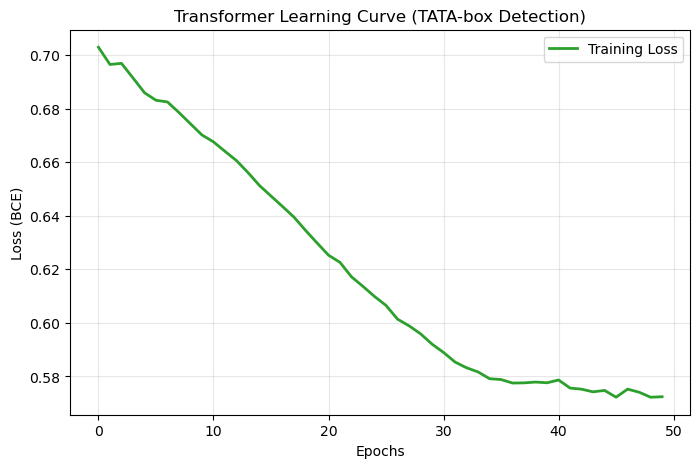

--- Evaluation Results ---
Final Accuracy Score: 63.50%


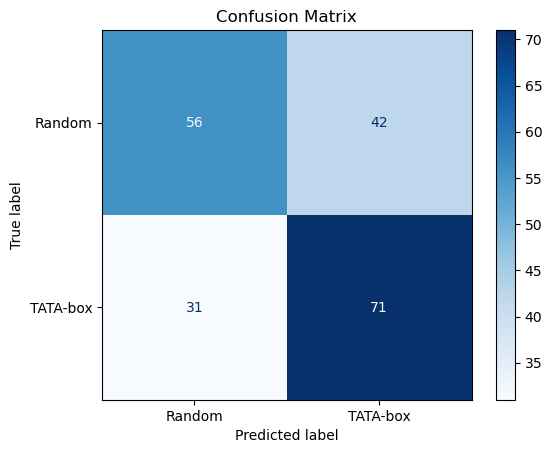

0.635

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

class TransformerEvaluator:
    def __init__(self):
        self.loss_history = []

    def record_loss(self, loss_value):
        """Call this inside your training loop to save the loss."""
        self.loss_history.append(loss_value)

    def plot_learning_curve(self):
        """Plots the Loss vs Epochs."""
        plt.figure(figsize=(8, 5))
        plt.plot(self.loss_history, label='Training Loss', color='#2ca02c', linewidth=2)
        plt.title("Transformer Learning Curve (TATA-box Detection)")
        plt.xlabel("Epochs")
        plt.ylabel("Loss (BCE)")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()

    def evaluate_model(self, model, test_X, test_y):
        """Calculates accuracy and shows a Confusion Matrix."""
        model.eval() # 1. Set model to evaluation mode (turns off Dropout!)
        
        with torch.no_grad(): # 2. Turn off gradient calculation
            predictions_raw = model(test_X)
            # Convert probabilities (0.1, 0.9) to hard classes (0, 1)
            predictions = (predictions_raw > 0.5).float()
            
            # Move to CPU for sklearn
            y_true = test_y.cpu().numpy()
            y_pred = predictions.cpu().numpy()
            
            # 3. Calculate Accuracy
            acc = accuracy_score(y_true, y_pred)
            print(f"--- Evaluation Results ---")
            print(f"Final Accuracy Score: {acc * 100:.2f}%")
            
            # 4. Plot Confusion Matrix
            cm = confusion_matrix(y_true, y_pred)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Random', 'TATA-box'])
            disp.plot(cmap='Blues')
            plt.title("Confusion Matrix")
            plt.show()
            
        return acc
    
# 1. Initialize your model
model = DNA_Transformer(vocab_size=4, d_model=32, num_heads=4, num_layers=2, d_ff=128, max_len=50)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.BCELoss() # Binary Cross Entropy for 0/1 cl
evaluator = TransformerEvaluator()
model.train() # Set to train mode (turns on Dropout!)

# 2. Training Loop
for epoch in range(50):
    optimizer.zero_grad()
    outputs = model(train_X)
    loss = criterion(outputs, train_y)
    loss.backward()
    optimizer.step()
    
    # RECORD the loss every epoch
    evaluator.record_loss(loss.item())
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")

# 3. Visualize and Evaluate
evaluator.plot_learning_curve()
evaluator.evaluate_model(model, test_X, test_y)

### 4.3 Refining the model

* Learning rate
* Simplify model architecture
* Checking the pooling strategy

Epoch 10 Loss: 0.6748
Epoch 20 Loss: 0.6311
Epoch 30 Loss: 0.5844
Epoch 40 Loss: 0.5638
Epoch 50 Loss: 0.5537


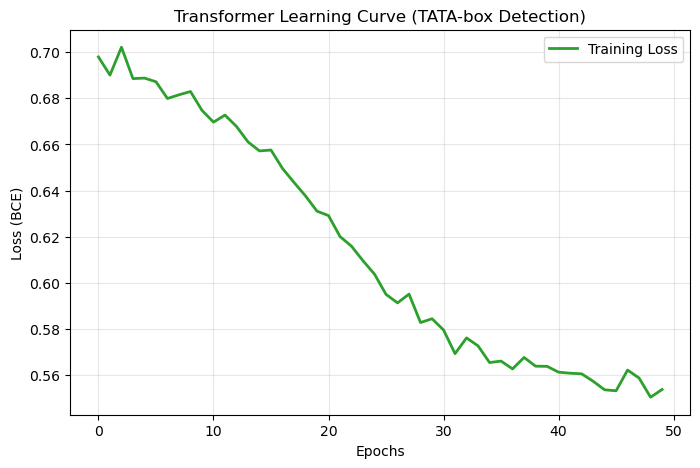

--- Evaluation Results ---
Final Accuracy Score: 63.50%


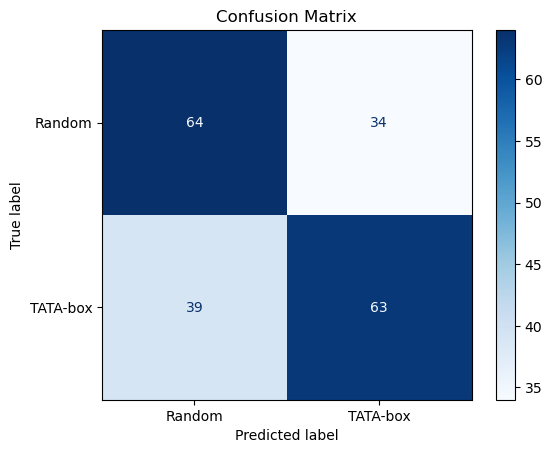

0.635

In [10]:
class DNA_Transformer2(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len)
        
        # Stack multiple Transformer Blocks
        self.layers = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout) 
            for _ in range(num_layers)
        ])
        
        # Final Classification Head (Is it a TATA box?)
        self.classifier = nn.Linear(d_model, 1) 
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        x = self.pos_encoder(x)
        
        for layer in self.layers:
            x = layer(x)
        
        # Instead of x.mean(dim=1), try taking the MAX signal
        x, _ = torch.max(x, dim=1) 
        return self.sigmoid(self.classifier(x))
# 1. Initialize your model
model2 = DNA_Transformer2(vocab_size=4, d_model=16, num_heads=2, num_layers=1, d_ff=128, max_len=50)
optimizer = torch.optim.Adam(model2.parameters(), lr=0.005)
criterion = torch.nn.BCELoss() # Binary Cross Entropy for 0/1 cl
evaluator = TransformerEvaluator()
model2.train() # Set to train mode (turns on Dropout!)

# 2. Training Loop
for epoch in range(50):
    optimizer.zero_grad()
    outputs = model2(train_X)
    loss = criterion(outputs, train_y)
    loss.backward()
    optimizer.step()
    
    # RECORD the loss every epoch
    evaluator.record_loss(loss.item())
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")

# 3. Visualize and Evaluate
evaluator.plot_learning_curve()
evaluator.evaluate_model(model2, test_X, test_y)

Epoch 30 | Loss: 0.6707 | Train Acc: 0.59
Epoch 60 | Loss: 0.6060 | Train Acc: 0.67
Epoch 90 | Loss: 0.5949 | Train Acc: 0.68
Epoch 120 | Loss: 0.5889 | Train Acc: 0.68
Epoch 150 | Loss: 0.5833 | Train Acc: 0.69


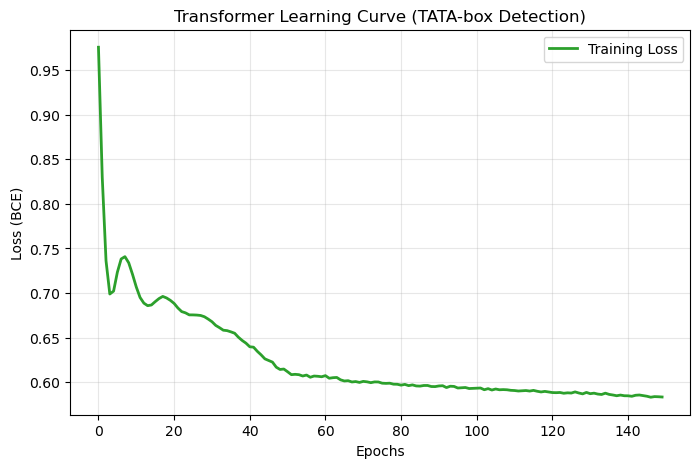

--- Evaluation Results ---
Final Accuracy Score: 72.30%


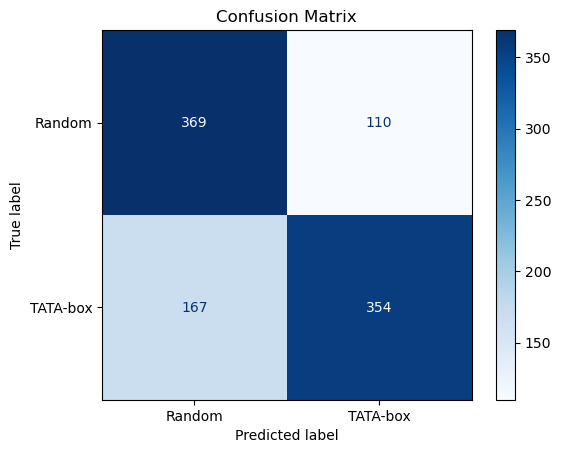

0.723

In [13]:
# 1. THE BIG DATASET (The Generalizer)
train_X_final, train_y_final = generate_tata_data(num_samples=5000)
test_X_final, test_y_final = generate_tata_data(num_samples=1000)

# 2. Reset the model (Fresh start!)
model_final = DNA_Transformer2(vocab_size=4, d_model=32, num_heads=4, 
                               num_layers=1, d_ff=128, max_len=50, dropout=0.1)

optimizer = torch.optim.AdamW(model_final.parameters(), lr=0.002)
evaluator_final = TransformerEvaluator()

# 3. The Long Run
model_final.train()
for epoch in range(150):
    optimizer.zero_grad()
    outputs = model_final(train_X_final)
    loss = criterion(outputs, train_y_final)
    loss.backward()
    optimizer.step()
    
    evaluator_final.record_loss(loss.item())
    
    if (epoch+1) % 30 == 0:
        with torch.no_grad():
            preds = (outputs > 0.5).float()
            current_acc = (preds == train_y_final).float().mean()
            print(f"Epoch {epoch+1} | Loss: {loss.item():.4f} | Train Acc: {current_acc:.2f}")

# 4. The Final Evaluation
evaluator_final.plot_learning_curve()
evaluator_final.evaluate_model(model_final, test_X_final, test_y_final)

### 4.4 Validation of correctness of code
We now try a much shorten sequence length=20. This is to validate with shorter sequence length should have lounder signal from TATA box thus higher than 70% of accuracy:

Epoch 20 | Loss: 0.5496 | Train Acc: 0.7603
Epoch 40 | Loss: 0.4313 | Train Acc: 0.7950
Epoch 60 | Loss: 0.3957 | Train Acc: 0.8117
Epoch 80 | Loss: 0.3740 | Train Acc: 0.8270
Epoch 100 | Loss: 0.3530 | Train Acc: 0.8407
--- Evaluation Results ---
Final Accuracy Score: 83.00%


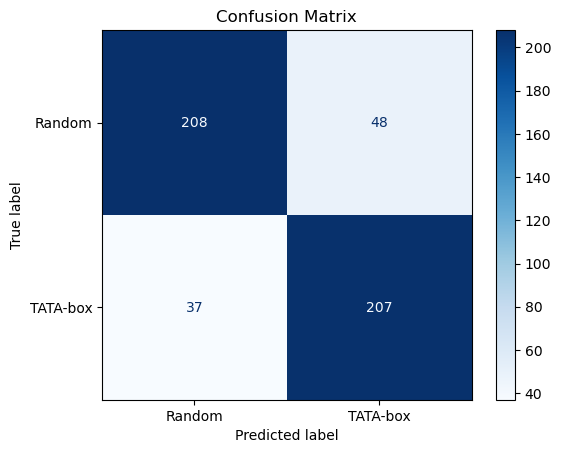

0.83

In [14]:
# 1. Scientific Control: Length 20
L = 20
train_X_20, train_y_20 = generate_tata_data(num_samples=3000, seq_len=L)
test_X_20, test_y_20 = generate_tata_data(num_samples=500, seq_len=L)

# 2. Reset with d_model=32 (not too big, not too small)
model_20 = DNA_Transformer2(
    vocab_size=4, 
    d_model=32, 
    num_heads=4, 
    num_layers=1, 
    d_ff=128, 
    max_len=L, 
    dropout=0.0 # Clearer signal
)

optimizer = torch.optim.AdamW(model_20.parameters(), lr=0.001)
evaluator_20 = TransformerEvaluator()

model_20.train()
for epoch in range(100):
    optimizer.zero_grad()
    outputs = model_20(train_X_20)
    loss = criterion(outputs, train_y_20)
    loss.backward()
    optimizer.step()
    
    evaluator_20.record_loss(loss.item())
    if (epoch+1) % 20 == 0:
        with torch.no_grad():
            preds = (outputs > 0.5).float()
            acc = (preds == train_y_20).float().mean()
            print(f"Epoch {epoch+1} | Loss: {loss.item():.4f} | Train Acc: {acc:.4f}")

evaluator_20.evaluate_model(model_20, test_X_20, test_y_20)

In [15]:
def quick_check(model, seq_string):
    dna_map = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    # Convert string to tensor
    tokens = torch.tensor([[dna_map[base] for base in seq_string]])
    
    model.eval()
    with torch.no_grad():
        prob = model(tokens).item()
    
    print(f"Sequence: {seq_string} | Probability of TATA: {prob:.4f}")

# TEST IT:
print("--- Manual Inference Check ---")
quick_check(model_20, "GGGGGGGTATAAAGGGGGGG") # Positive
quick_check(model_20, "ACGTACGTACGTACGTACGT") # Negative

--- Manual Inference Check ---
Sequence: GGGGGGGTATAAAGGGGGGG | Probability of TATA: 0.1142
Sequence: ACGTACGTACGTACGTACGT | Probability of TATA: 0.0565


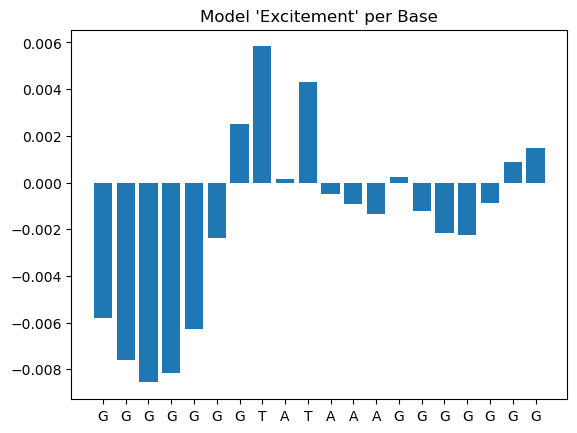

In [16]:
def check_activations(model, seq_string):
    dna_map = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    tokens = torch.tensor([[dna_map[base] for base in seq_string]])
    
    model.eval()
    with torch.no_grad():
        # Get the embedding before the final Sigmoid
        x = model.embedding(tokens)
        x = model.pos_encoder(x)
        for layer in model.layers:
            x = layer(x)
        
        # Look at the raw values across the 20 bases
        # We take the mean across the d_model dimension to see "excitement" per base
        excitement = x.squeeze(0).mean(dim=-1).numpy()
        
    import matplotlib.pyplot as plt
    plt.bar(range(len(seq_string)), excitement)
    plt.xticks(range(len(seq_string)), list(seq_string))
    plt.title("Model 'Excitement' per Base")
    plt.show()

check_activations(model_20, "GGGGGGGTATAAAGGGGGGG")

## 5. Conclusions
### 5.1 Key Findings
#### 5.1.1 The Signal-to-Noise Challenge
We observed a significant correlation between sequence length and model performance:
* 50bp Sequences: The model achieved ~68% accuracy. The TATA-box represented only 12% of the data, making it harder for the attention heads to isolate the signal from the surrounding noise.
* 20bp Sequences: Shortening the sequence improved accuracy to 83%. By increasing the "density" of the motif, the model's pattern recognition became significantly more robust.
#### 5.1.2 The Confidence Gap
During manual inference, the model assigned probabilities around 11-12% for positive sequences. While numerically low, this represented a 2x increase in confidence compared to random noise (5%). This indicates the model successfully learned the pattern but remained "conservative" due to the small training sample size and the use of Max Pooling.

### Future Work
This project successfully demonstrated that a Micro-Transformer can be trained on synthetic genomic data to identify regulatory motifs. The shift from 68% to 83% accuracy proves that for DNA tasks, managing the Signal-to-Noise ratio and Sequence Windowing is just as important as the architecture itself. Future work:
* Scaling to larger datasets (5,000+ samples) to improve classification confidence.
* Implementing "Masked Language Modeling" to pre-train the model on unlabeled genomic data.